## Task 3 — Exploratory Statistical Analysis of Pixel Data

**Purpose:** Begin applying statistical concepts by treating pixel intensities as random variables and studying their probability distributions. This step helps understand how pixel values vary across the dataset and across different digits.

**Objectives:**
- Treat pixel intensities as random variables
- Analyze distributions of pixel values
- Compute descriptive statistics
- Observe how pixel distributions vary across digits

**Inputs:**
- `data/processed/X_train.npy`
- `data/processed/y_train.npy`

**Outputs:**
- `images/pixel_distribution.png`
- `images/average_digits.png`
- `results/statistical_summary.csv`

## Setup and Imports

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Improve plot readability in notebooks
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
IMAGE_DIR = PROJECT_ROOT / "images"
RESULTS_DIR = PROJECT_ROOT / "results"

IMAGE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Load processed training data
X_train = np.load(DATA_DIR / "X_train.npy")
y_train = np.load(DATA_DIR / "y_train.npy")

print("Dataset loaded successfully")
print(f"Training images shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Image dimensions: 28x28 pixels")

Dataset loaded successfully
Training images shape: (56000, 784)
Training labels shape: (56000,)
Image dimensions: 28x28 pixels


## 1. Treating Pixels as Random Variables

**Concept:** Each pixel location in the image can be considered a random variable whose value represents the intensity of that pixel across many samples. Each image provides one observation of that variable.

**Purpose:** To analyze statistical behavior of image features.

In [4]:
# Example: Treating a specific pixel position as a random variable
# Pixel at center of image (14, 14) in 28x28 image
center_pixel_idx = 14 * 28 + 14  # Convert 2D position to 1D index
center_pixel_values = X_train[:, center_pixel_idx]

print(f"Pixel position (14, 14) - Center of image")
print(f"Number of observations: {len(center_pixel_values)}")
print(f"Mean intensity: {center_pixel_values.mean():.4f}")
print(f"Standard deviation: {center_pixel_values.std():.4f}")
print(f"Min value: {center_pixel_values.min():.4f}")
print(f"Max value: {center_pixel_values.max():.4f}")

Pixel position (14, 14) - Center of image
Number of observations: 56000
Mean intensity: 0.5132
Standard deviation: 0.4458
Min value: 0.0000
Max value: 1.0000


## 2. Overall Pixel Intensity Distribution

**Purpose:** Analyze the distribution of all pixel values across the entire dataset to understand the general characteristics of pixel intensities.

In [5]:
# Flatten all pixel values into a single array
all_pixels = X_train.flatten()

print(f"Total number of pixel observations: {len(all_pixels):,}")
print(f"Shape of flattened array: {all_pixels.shape}")

Total number of pixel observations: 43,904,000
Shape of flattened array: (43904000,)


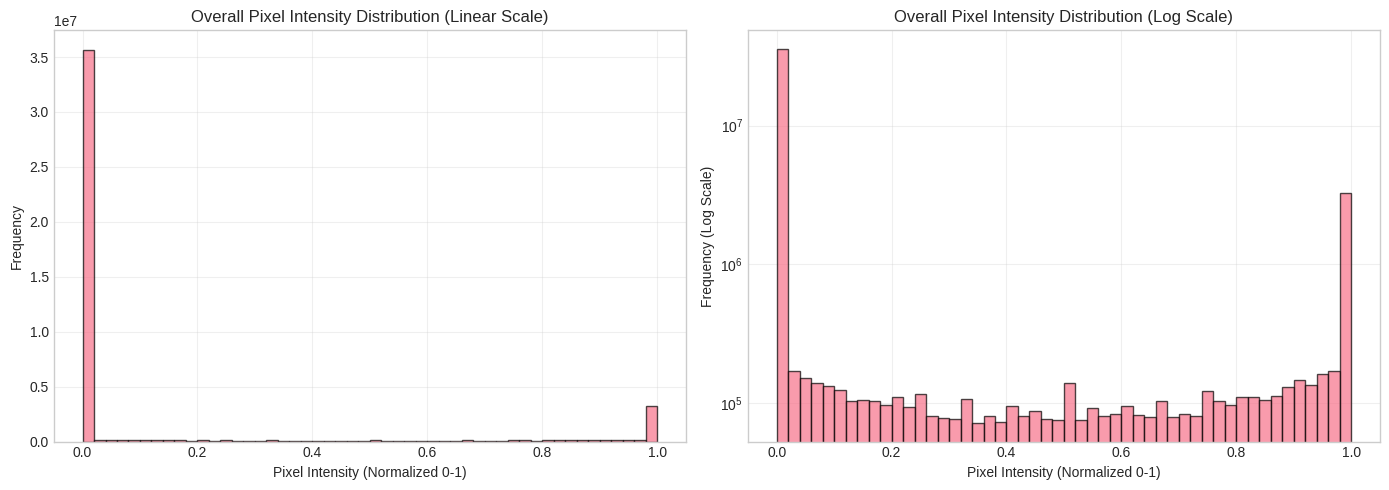

Saved: images/pixel_distribution.png


In [6]:
# Plot histogram of overall pixel intensity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with linear scale
axes[0].hist(all_pixels, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Overall Pixel Intensity Distribution (Linear Scale)', fontsize=12)
axes[0].set_xlabel('Pixel Intensity (Normalized 0-1)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Histogram with log scale for y-axis to better see distribution
axes[1].hist(all_pixels, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_yscale('log')
axes[1].set_title('Overall Pixel Intensity Distribution (Log Scale)', fontsize=12)
axes[1].set_xlabel('Pixel Intensity (Normalized 0-1)')
axes[1].set_ylabel('Frequency (Log Scale)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGE_DIR / "pixel_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print('Saved: images/pixel_distribution.png')

**Observations:**
- Most pixels have values near zero (background pixels)
- The distribution is highly skewed toward zero
- This is expected since large areas of MNIST images are blank

## 3. Descriptive Statistics

**Purpose:** Compute statistical properties of pixel values to understand central tendency and dispersion of the data.

In [7]:
# Compute descriptive statistics for overall pixel distribution
mean_pixel = np.mean(all_pixels)
variance_pixel = np.var(all_pixels)
std_pixel = np.std(all_pixels)
min_pixel = np.min(all_pixels)
max_pixel = np.max(all_pixels)
median_pixel = np.median(all_pixels)

print("Descriptive Statistics for Overall Pixel Intensity Distribution")
print("-" * 60)
print(f"Mean:              {mean_pixel:.6f}")
print(f"Variance:          {variance_pixel:.6f}")
print(f"Standard Deviation: {std_pixel:.6f}")
print(f"Median:            {median_pixel:.6f}")
print(f"Minimum:           {min_pixel:.6f}")
print(f"Maximum:           {max_pixel:.6f}")
print(f"Range:             {max_pixel - min_pixel:.6f}")

Descriptive Statistics for Overall Pixel Intensity Distribution
------------------------------------------------------------
Mean:              0.131107
Variance:          0.095263
Standard Deviation: 0.308647
Median:            0.000000
Minimum:           0.000000
Maximum:           1.000000
Range:             1.000000


In [8]:
# Create summary statistics DataFrame
statistical_summary = pd.DataFrame({
    'Statistic': [
        'Mean',
        'Variance',
        'Standard Deviation',
        'Median',
        'Minimum',
        'Maximum',
        'Range'
    ],
    'Value': [
        mean_pixel,
        variance_pixel,
        std_pixel,
        median_pixel,
        min_pixel,
        max_pixel,
        max_pixel - min_pixel
    ]
})

print("\nStatistical Summary Table:")
print(statistical_summary.to_string(index=False))


Statistical Summary Table:
         Statistic    Value
              Mean 0.131107
          Variance 0.095263
Standard Deviation 0.308647
            Median 0.000000
           Minimum 0.000000
           Maximum 1.000000
             Range 1.000000


## 4. Pixel Distribution for Individual Digits

**Purpose:** Study how pixel intensity distributions differ for specific digits to understand digit-specific characteristics.

In [9]:
# Compute mean pixel intensity per digit
digit_means = {}
digit_stds = {}
digit_pixels = {}

for digit in range(10):
    digit_mask = y_train == digit
    digit_data = X_train[digit_mask]
    digit_pixels[digit] = digit_data.flatten()
    digit_means[digit] = np.mean(digit_pixels[digit])
    digit_stds[digit] = np.std(digit_pixels[digit])

# Display statistics per digit
print("Mean Pixel Intensity by Digit:")
print("-" * 40)
for digit in range(10):
    print(f"Digit {digit}: Mean = {digit_means[digit]:.6f}, Std = {digit_stds[digit]:.6f}")

Mean Pixel Intensity by Digit:
----------------------------------------
Digit 0: Mean = 0.173523, Std = 0.347860
Digit 1: Mean = 0.076150, Std = 0.244560
Digit 2: Mean = 0.149216, Std = 0.326234
Digit 3: Mean = 0.142245, Std = 0.318769
Digit 4: Mean = 0.121733, Std = 0.297988
Digit 5: Mean = 0.129278, Std = 0.304257
Digit 6: Mean = 0.138112, Std = 0.315762
Digit 7: Mean = 0.114814, Std = 0.292116
Digit 8: Mean = 0.150573, Std = 0.325690
Digit 9: Mean = 0.122893, Std = 0.299019


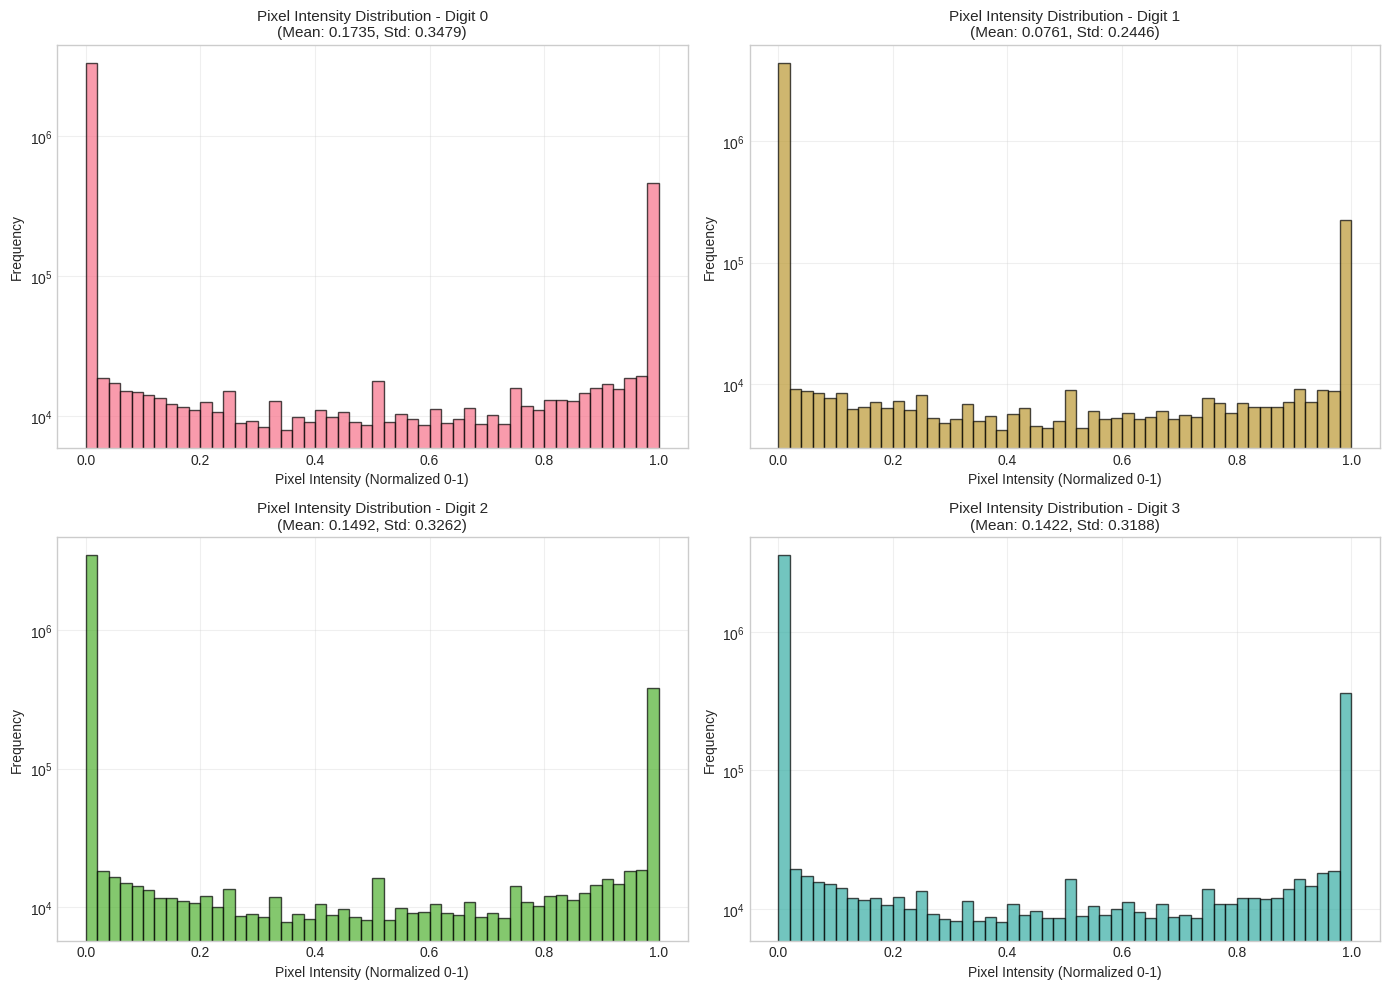

Saved: images/digit_pixel_distributions.png


In [10]:
# Plot histograms for selected digits (0, 1, 2, 3)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
selected_digits = [0, 1, 2, 3]

for idx, digit in enumerate(selected_digits):
    ax = axes[idx // 2, idx % 2]
    ax.hist(digit_pixels[digit], bins=50, edgecolor='black', alpha=0.7, color=sns.color_palette()[idx])
    ax.set_title(f'Pixel Intensity Distribution - Digit {digit}\n(Mean: {digit_means[digit]:.4f}, Std: {digit_stds[digit]:.4f})', 
                 fontsize=11)
    ax.set_xlabel('Pixel Intensity (Normalized 0-1)')
    ax.set_ylabel('Frequency')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGE_DIR / "digit_pixel_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print('Saved: images/digit_pixel_distributions.png')

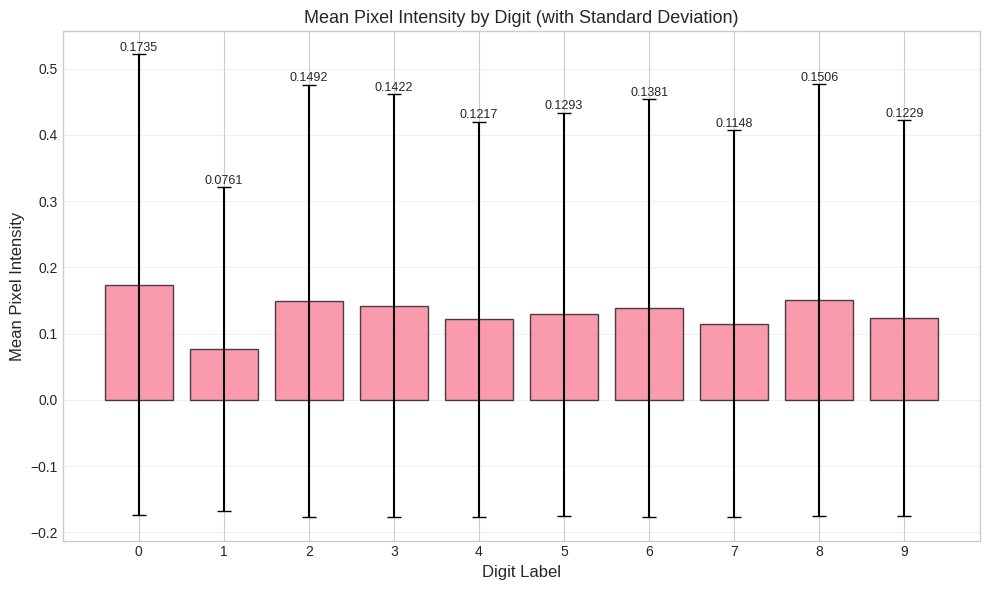

Saved: images/mean_intensity_by_digit.png


In [11]:
# Compare mean pixel intensities across all digits
fig, ax = plt.subplots(figsize=(10, 6))
digits = list(range(10))
means = [digit_means[d] for d in digits]
stds = [digit_stds[d] for d in digits]

x_pos = np.arange(len(digits))
bars = ax.bar(x_pos, means, yerr=stds, capsize=5, alpha=0.7, edgecolor='black')
ax.set_xlabel('Digit Label', fontsize=12)
ax.set_ylabel('Mean Pixel Intensity', fontsize=12)
ax.set_title('Mean Pixel Intensity by Digit (with Standard Deviation)', fontsize=13)
ax.set_xticks(x_pos)
ax.set_xticklabels(digits)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (mean, std) in enumerate(zip(means, stds)):
    ax.text(i, mean + std + 0.001, f'{mean:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(IMAGE_DIR / "mean_intensity_by_digit.png", dpi=150, bbox_inches="tight")
plt.show()

print('Saved: images/mean_intensity_by_digit.png')

**Observations:**
- Different digits may have different mean pixel intensities
- This could be due to stroke thickness, digit complexity, or writing style
- Digits with more strokes or thicker lines may have higher mean intensities

## 5. Distribution of Specific Pixel Locations

**Purpose:** Understand how certain pixel locations behave across the dataset. Pixels near the center may show higher intensity variance because many digits pass through that region.

In [12]:
# Select specific pixel positions to analyze
# Center pixel (14, 14)
# Edge pixel (0, 0) - top-left corner
# Edge pixel (27, 27) - bottom-right corner
# Middle-left (14, 0)
# Middle-right (14, 27)

pixel_positions = {
    'Center (14, 14)': (14, 14),
    'Top-Left (0, 0)': (0, 0),
    'Bottom-Right (27, 27)': (27, 27),
    'Middle-Left (14, 0)': (14, 0),
    'Middle-Right (14, 27)': (14, 27)
}

pixel_data = {}
pixel_stats = {}

for name, (row, col) in pixel_positions.items():
    pixel_idx = row * 28 + col
    pixel_values = X_train[:, pixel_idx]
    pixel_data[name] = pixel_values
    pixel_stats[name] = {
        'mean': np.mean(pixel_values),
        'std': np.std(pixel_values),
        'min': np.min(pixel_values),
        'max': np.max(pixel_values)
    }
    print(f"{name}:")
    print(f"  Mean: {pixel_stats[name]['mean']:.6f}, Std: {pixel_stats[name]['std']:.6f}")
    print(f"  Range: [{pixel_stats[name]['min']:.6f}, {pixel_stats[name]['max']:.6f}]")
    print()

Center (14, 14):
  Mean: 0.513228, Std: 0.445761
  Range: [0.000000, 1.000000]

Top-Left (0, 0):
  Mean: 0.000000, Std: 0.000000
  Range: [0.000000, 0.000000]

Bottom-Right (27, 27):
  Mean: 0.000000, Std: 0.000000
  Range: [0.000000, 0.000000]

Middle-Left (14, 0):
  Mean: 0.000008, Std: 0.001873
  Range: [0.000000, 0.443137]

Middle-Right (14, 27):
  Mean: 0.000009, Std: 0.001288
  Range: [0.000000, 0.203922]



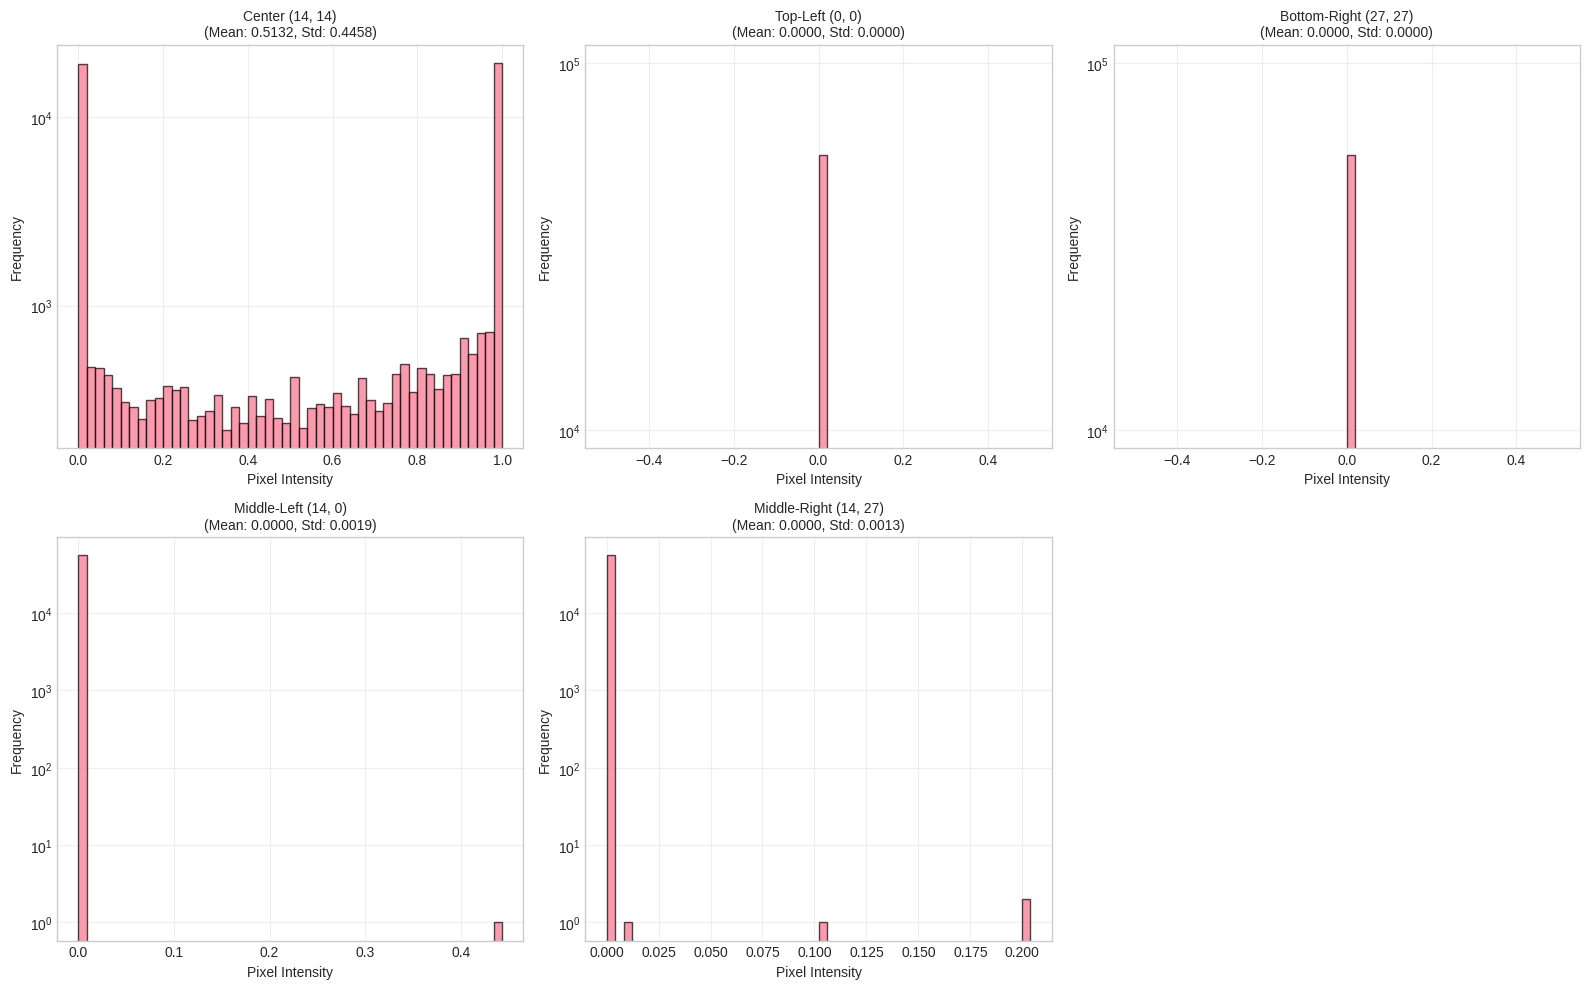

Saved: images/pixel_location_distributions.png


In [13]:
# Plot histograms for selected pixel locations
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, values) in enumerate(pixel_data.items()):
    ax = axes[idx]
    ax.hist(values, bins=50, edgecolor='black', alpha=0.7)
    stats = pixel_stats[name]
    ax.set_title(f'{name}\n(Mean: {stats["mean"]:.4f}, Std: {stats["std"]:.4f})', fontsize=10)
    ax.set_xlabel('Pixel Intensity')
    ax.set_ylabel('Frequency')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

# Remove the last subplot if we have odd number
if len(pixel_data) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig(IMAGE_DIR / "pixel_location_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print('Saved: images/pixel_location_distributions.png')

**Key Insights:**
- Center pixels typically show higher variance because many digits pass through the center
- Edge pixels (corners) are more likely to be zero (background)
- This analysis helps identify which pixel locations carry more information

## 6. Average Image for Each Digit

**Purpose:** Compute and visualize the average image for each digit class to show the typical structure of each digit.

In [14]:
# Compute average image for each digit
average_images = {}

for digit in range(10):
    digit_mask = y_train == digit
    digit_data = X_train[digit_mask]
    # Compute mean pixel intensity at each location
    average_image = np.mean(digit_data, axis=0)
    average_images[digit] = average_image.reshape(28, 28)
    
    print(f"Digit {digit}: {np.sum(digit_mask)} samples")

Digit 0: 5560 samples
Digit 1: 6277 samples
Digit 2: 5610 samples
Digit 3: 5708 samples
Digit 4: 5529 samples
Digit 5: 5040 samples
Digit 6: 5480 samples
Digit 7: 5790 samples
Digit 8: 5468 samples
Digit 9: 5538 samples


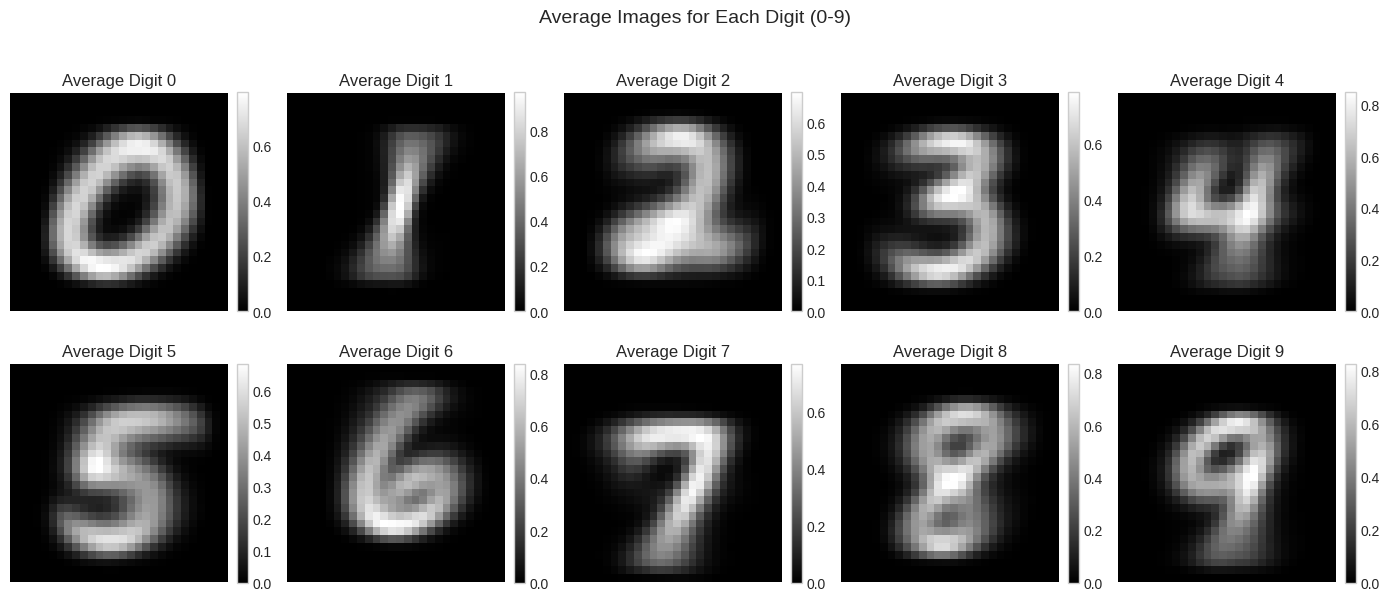

Saved: images/average_digits.png


In [15]:
# Visualize average images for all digits
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    im = ax.imshow(average_images[digit], cmap='gray', interpolation='nearest')
    ax.set_title(f'Average Digit {digit}', fontsize=12)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Average Images for Each Digit (0-9)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "average_digits.png", dpi=150, bbox_inches="tight")
plt.show()

print('Saved: images/average_digits.png')

**Observations:**
- Average images reveal the typical structure of each digit
- Brighter regions indicate pixels that are frequently active for that digit
- This visualization helps understand which regions of the image are most informative for each digit

## 7. Save Statistical Summary

**Purpose:** Save comprehensive statistical summary to CSV file for later reference.

In [16]:
# Create comprehensive statistical summary
summary_data = []

# Overall statistics
summary_data.append({
    'Category': 'Overall',
    'Digit': 'All',
    'Mean': mean_pixel,
    'Variance': variance_pixel,
    'Std': std_pixel,
    'Min': min_pixel,
    'Max': max_pixel,
    'Median': median_pixel
})

# Per-digit statistics
for digit in range(10):
    summary_data.append({
        'Category': 'Per-Digit',
        'Digit': digit,
        'Mean': digit_means[digit],
        'Variance': np.var(digit_pixels[digit]),
        'Std': digit_stds[digit],
        'Min': np.min(digit_pixels[digit]),
        'Max': np.max(digit_pixels[digit]),
        'Median': np.median(digit_pixels[digit])
    })

# Pixel location statistics
for name, stats in pixel_stats.items():
    summary_data.append({
        'Category': 'Pixel-Location',
        'Digit': name,
        'Mean': stats['mean'],
        'Variance': stats['std'] ** 2,
        'Std': stats['std'],
        'Min': stats['min'],
        'Max': stats['max'],
        'Median': np.median(pixel_data[name])
    })

# Create DataFrame and save
statistical_summary_df = pd.DataFrame(summary_data)
statistical_summary_df.to_csv(RESULTS_DIR / "statistical_summary.csv", index=False)

print("Statistical summary saved successfully!")
print(f"\nSummary shape: {statistical_summary_df.shape}")
print("\nFirst few rows:")
print(statistical_summary_df.head(15))

Statistical summary saved successfully!

Summary shape: (16, 8)

First few rows:
          Category                  Digit      Mean  Variance       Std  Min  \
0          Overall                    All  0.131107  0.095263  0.308647  0.0   
1        Per-Digit                      0  0.173523  0.121007  0.347860  0.0   
2        Per-Digit                      1  0.076150  0.059810  0.244560  0.0   
3        Per-Digit                      2  0.149216  0.106429  0.326234  0.0   
4        Per-Digit                      3  0.142245  0.101613  0.318769  0.0   
5        Per-Digit                      4  0.121733  0.088797  0.297988  0.0   
6        Per-Digit                      5  0.129278  0.092572  0.304257  0.0   
7        Per-Digit                      6  0.138112  0.099706  0.315762  0.0   
8        Per-Digit                      7  0.114814  0.085332  0.292116  0.0   
9        Per-Digit                      8  0.150573  0.106074  0.325690  0.0   
10       Per-Digit                     

## Key Observations Summary

**Why many pixels have values near zero:**
- Large areas of MNIST images are blank (background)
- Most pixels are not part of the digit strokes
- This creates a highly skewed distribution with most values near zero

**How digit strokes affect pixel intensity distribution:**
- Digits with thicker strokes or more complex structures tend to have higher mean pixel intensities
- The distribution varies by digit, reflecting differences in stroke patterns

**Which regions of images carry more information:**
- Center regions typically show higher variance because most digits pass through the center
- Edge pixels (especially corners) are more likely to be background (zero)
- Average digit images reveal which pixel locations are most informative for each digit class